In [1]:
# ==========================================================
# SECTION 0: INSTALL REQUIRED LIBRARIES
# Run this cell once (skip if already installed)
# ==========================================================
!pip install shap lime eli5 seaborn

Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/43.0 MB ? eta -:--:--
    --------------------------------------- 0.8/43.0 MB 5.0 MB/s eta 0:00:09
    --------------------------------------- 0.8/43.0 MB 5.0 MB/s eta 0:00:09
    --------------------------------------- 1.0/43.0 MB 1.6 MB/s eta 0:00:27
   - -------------------------------------- 1.6/43.0 MB 1.7 MB/s eta 0:00:25
   - -------------------------------------- 2.1/43.0 MB 1.9 MB/s eta 0:00:22
   - -------------------------------------- 2.1/43.0 MB 1.9 MB/s eta 0:00:22
   -- ------------------------------------- 2.4/43.0 MB 1.6 


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Libraries imported successfully.
Data prepared successfully.
Training samples: (712, 6)
Testing samples: (179, 6)
Model trained successfully.
Model Accuracy: 0.7988826815642458
SHAP values shape: (179, 6, 2)
.values =
array([[[ 0.07037424, -0.07037424],
        [ 0.15870929, -0.15870929],
        [ 0.09369034, -0.09369034],
        [-0.02083954,  0.02083954],
        [-0.05775878,  0.05775878],
        [ 0.00693401, -0.00693401]],

       [[ 0.05441586, -0.05441586],
        [ 0.22681283, -0.22681283],
        [ 0.01511387, -0.01511387],
        [-0.00248361,  0.00248361],
        [ 0.00955719, -0.00955719],
        [ 0.04569341, -0.04569341]],

       [[ 0.05324803, -0.05324803],
        [ 0.10221565, -0.10221565],
        [ 0.04727306, -0.04727306],
        [ 0.01104912, -0.01104912],
        [ 0.00801092, -0.00801092],
        [ 0.02931276, -0.02931276]],

       ...,

       [[ 0.22268141, -0.22268141],
        [-0.1617565 ,  0.1617565 ],
        [ 0.06341168, -0.06341168],
       

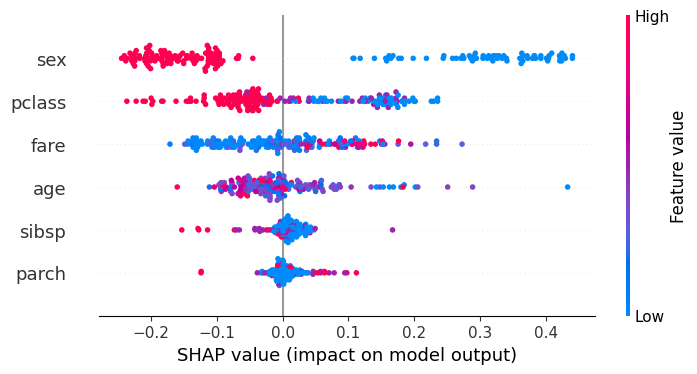

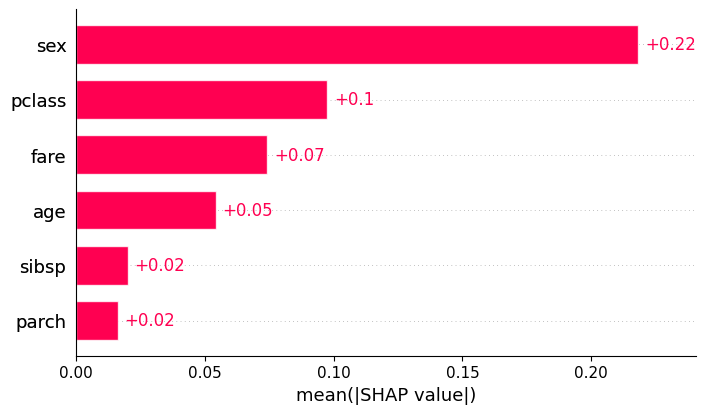

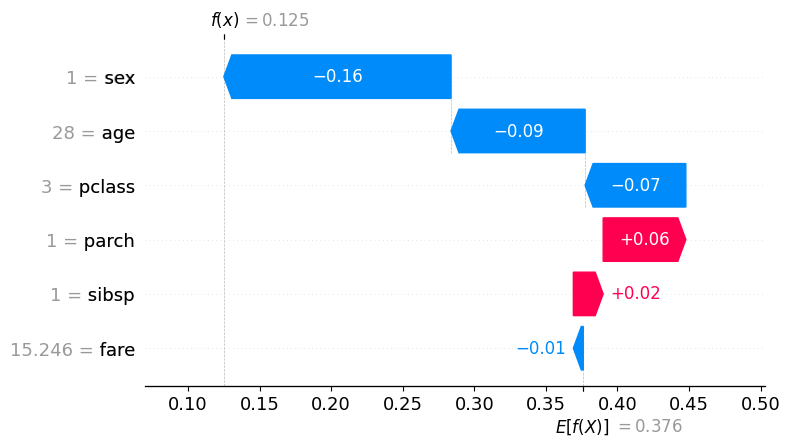

In [ ]:
# ==========================================================
# SECTION 1: IMPORT LIBRARIES
# ==========================================================
# Data handling
import pandas as pd
import numpy as np
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt

# Model building
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# Explainability tools
import shap
from lime.lime_tabular import LimeTabularExplainer
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
import eli5
from eli5.sklearn import PermutationImportance
# Improve plot readability
plt.rcParams["figure.figsize"] = (8, 6)
print("Libraries imported successfully.")
# ==========================================================
# SECTION 2: LOAD AND PREPROCESS DATA
# ==========================================================
# Load Titanic dataset from seaborn
df = sns.load_dataset("titanic")
# Select relevant columns
df = df[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']]
# Fill missing age values with median
df['age'] = df['age'].fillna(df['age'].median())
# Encode 'sex' (male=1, female=0)
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
# Separate features and target
X = df.drop('survived', axis=1)
y = df['survived']
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Data prepared successfully.")
print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)
# ==========================================================
# SECTION 3: MODEL TRAINING
# ==========================================================
# Initialize Random Forest
model = RandomForestClassifier(
    n_estimators=200,    # Number of trees
    random_state=42
)
# Train model
model.fit(X_train, y_train)
# Evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Model trained successfully.")
print("Model Accuracy:", accuracy)
# ==========================================================
# SECTION 4: SHAP
# ==========================================================
import shap
# Create explainer (auto-detects correct type)
explainer = shap.Explainer(model)
# Calculate SHAP values
shap_values = explainer(X_test)
print("SHAP values shape:", shap_values.values.shape)
print(shap_values)
# If 3D (binary classification), select class 1
if len(shap_values.values.shape) == 3:
    shap_values = shap_values[:, :, 1]
# Beeswarm plot (best global visualization)
shap.plots.beeswarm(shap_values)
shap.plots.bar(shap_values)
# Pick one passenger
sample_index = 0
shap.plots.waterfall(shap_values[sample_index])
